# Analysis of Algorithms - Python Examples
This notebook illustrates the formulas from Chapter 2 using simple Python code and visualizations.

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

## 1. Newton-Raphson Method (Eq. 2.1 & 2.2)

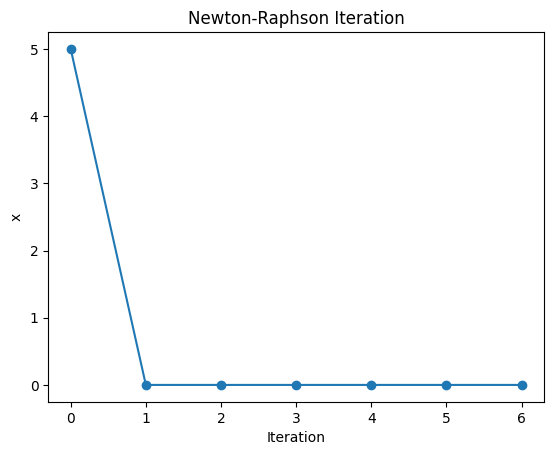

In [11]:
def newton_raphson(f, df, d2f, x0, max_iter=10):
    x = x0
    history = [x]
    for t in range(max_iter):
        x = x - df(x)/d2f(x)
        history.append(x)
    return history

f  = lambda x: x**2 - 2
df = lambda x: 2*x
d2f= lambda x: 2

history = newton_raphson(f, df, d2f, x0=5.0, max_iter=6)

plt.plot(history, marker="o")
plt.title("Newton-Raphson Iteration")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 2. General Iterative Algorithm (Eq. 2.4)

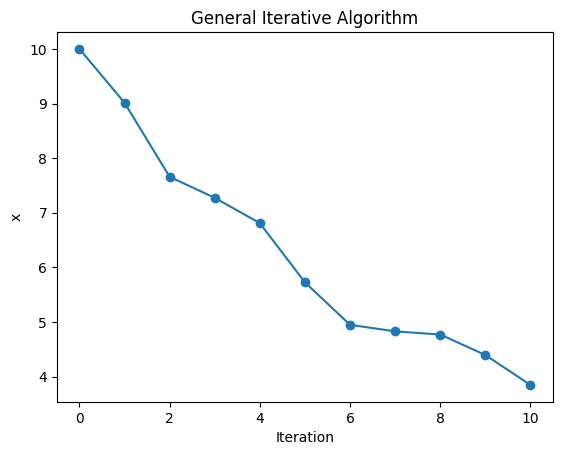

In [12]:
def simple_algorithm(x, p, eps):
    return x - p * x + eps

x = 10
history = [x]
for t in range(10):
    eps = random.uniform(-0.5, 0.5)
    x = simple_algorithm(x, p=0.1, eps=eps)
    history.append(x)

plt.plot(history, marker="o")
plt.title("General Iterative Algorithm")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 3. Population-Based Iteration (Eq. 2.5)

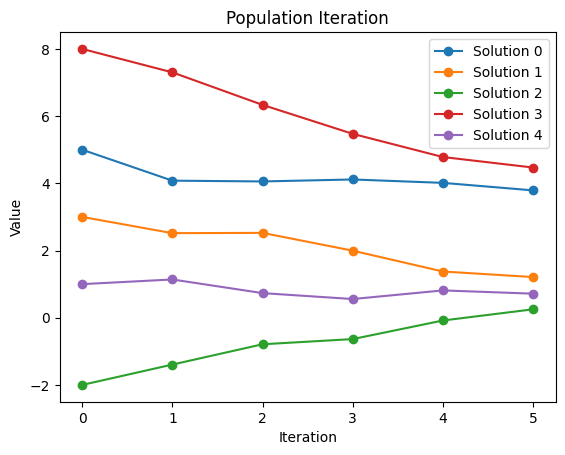

In [13]:
def population_update(X, p, eps):
    return X - p * X + eps

X = np.array([5, 3, -2, 8, 1], dtype=float)
history = [X.copy()]

for t in range(5):
    eps = np.random.uniform(-0.5, 0.5, size=len(X))
    X = population_update(X, p=0.1, eps=eps)
    history.append(X.copy())

history = np.array(history)
for i in range(history.shape[1]):
    plt.plot(history[:, i], marker="o", label=f"Solution {i}")
plt.title("Population Iteration")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.legend()
plt.show()

## 4. Self-Organization View (Eq. 2.9)

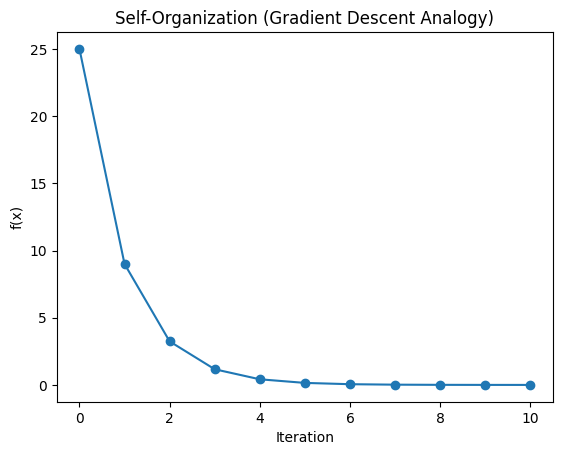

In [14]:
def objective(x):
    return x**2

x = 5
history = [objective(x)]
for t in range(10):
    x = x - 0.2 * (2*x)  # gradient descent
    history.append(objective(x))

plt.plot(history, marker="o")
plt.title("Self-Organization (Gradient Descent Analogy)")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.show()

## 5. Mutation Operator (Eq. 2.11)

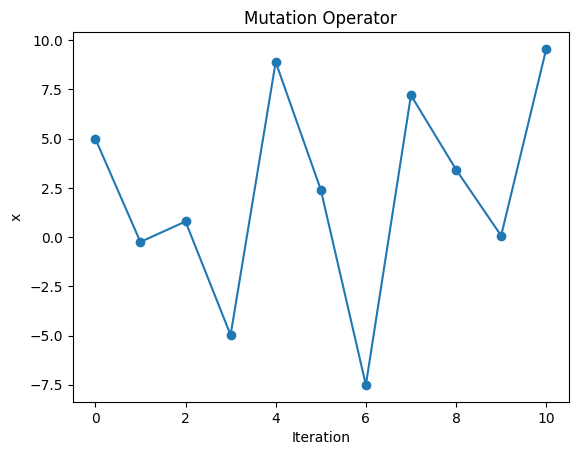

In [15]:
x = 5
history = [x]
for t in range(10):
    new_move = random.uniform(-10, 10)
    x = x + (new_move - x)
    history.append(x)

plt.plot(history, marker="o")
plt.title("Mutation Operator")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 6. Particle Swarm Optimization Update (Eq. 2.16 & 2.17)

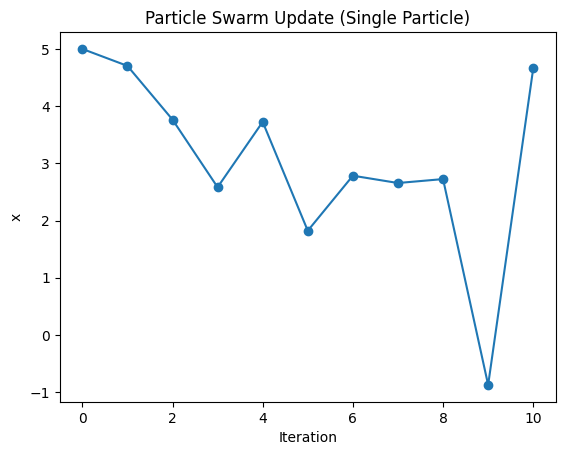

In [16]:
alpha, beta = 2, 2
g_best = 0.0
x, v = 5.0, 0.0
p_best = x

history = [x]
for t in range(10):
    eps1, eps2 = np.random.rand(), np.random.rand()
    v = v + alpha*eps1*(g_best - x) + beta*eps2*(p_best - x)
    x = x + v
    history.append(x)

plt.plot(history, marker="o")
plt.title("Particle Swarm Update (Single Particle)")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 7. Firefly Algorithm Move (Eq. 2.18)

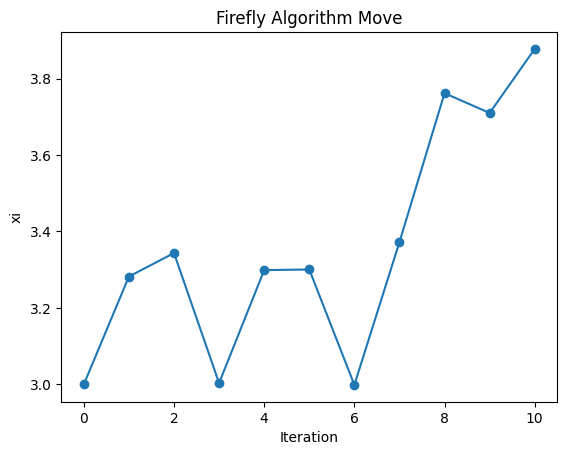

In [17]:
def firefly_move(xi, xj, beta0=1, gamma=1, alpha=0.2):
    rij = abs(xi - xj)
    attraction = beta0 * np.exp(-gamma * rij**2) * (xj - xi)
    random_step = alpha * np.random.randn()
    return xi + attraction + random_step

xi, xj = 3.0, -1.0
history = [xi]
for t in range(10):
    xi = firefly_move(xi, xj)
    history.append(xi)

plt.plot(history, marker="o")
plt.title("Firefly Algorithm Move")
plt.xlabel("Iteration")
plt.ylabel("xi")
plt.show()

## 8. Cuckoo Search - Lévy Flight (Eq. 2.19 & 2.20)

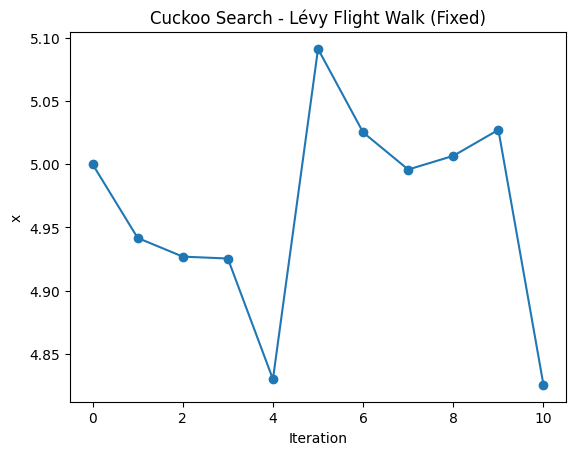

In [18]:
def levy_flight(Lambda=1.5):
    # Using the Mantegna algorithm
    sigma = (math.gamma(1+Lambda) * math.sin(math.pi*Lambda/2) /
            (math.gamma((1+Lambda)/2)*Lambda*2**((Lambda-1)/2)))**(1/Lambda)
    u = np.random.randn() * sigma
    v = np.random.randn()
    return u / abs(v)**(1/Lambda)

# Test run
x = 5.0
history = [x]
for t in range(10):
    step = levy_flight()
    x = x + 0.1 * step
    history.append(x)

import matplotlib.pyplot as plt
plt.plot(history, marker="o")
plt.title("Cuckoo Search - Lévy Flight Walk (Fixed)")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 9. Bat Algorithm Frequency Tuning (Eq. 2.22–2.24)

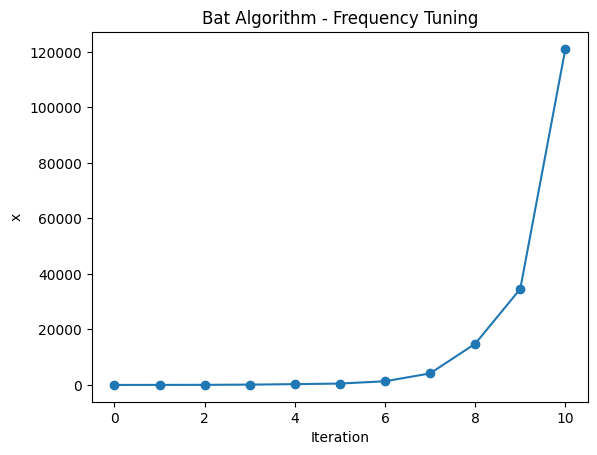

In [19]:
fmin, fmax = 0, 2
x, v = 5.0, 0.0
x_best = 0.0

history = [x]
for t in range(10):
    beta = np.random.rand()
    f = fmin + (fmax - fmin) * beta
    v = v + (x - x_best) * f
    x = x + v
    history.append(x)

plt.plot(history, marker="o")
plt.title("Bat Algorithm - Frequency Tuning")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()

## 10. Flower Pollination Algorithm (Eq. 2.28 & 2.30)

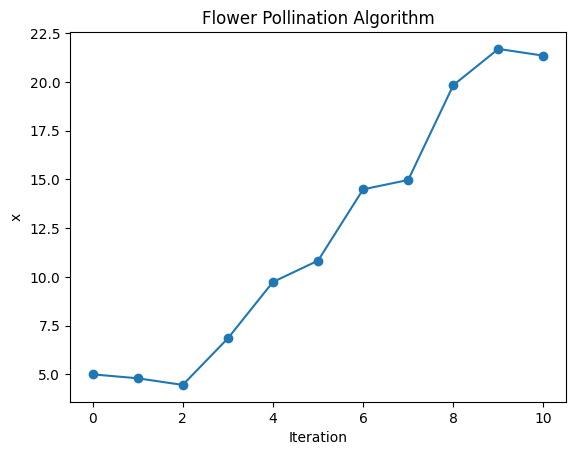

In [20]:
def global_pollination(x, g_best, gamma=0.1):
    return x + gamma * levy_flight() * (g_best - x)

def local_pollination(x, xj, xk, eps=None):
    if eps is None: eps = np.random.rand()
    return x + eps * (xj - xk)

x, g_best = 5.0, 0.0
xj, xk = 2.0, -3.0

history = [x]
for t in range(10):
    if np.random.rand() < 0.5:
        x = global_pollination(x, g_best)
    else:
        x = local_pollination(x, xj, xk)
    history.append(x)

plt.plot(history, marker="o")
plt.title("Flower Pollination Algorithm")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.show()